# PowerPredict - interaktivni pregled projekta

Ovaj notebook je vodič kroz najbitnije ideje, odluke i rezultate projekta. Cilj je pregled problema, pripremljenih podataka, rada baseline modela, rada GRU i LSTM modela, treniranja modela i rezultata.

Notebook očekuje da se pokreće iz root foldera projekta, tj. iz foldera `PowerPredict`.

In [42]:
from pathlib import Path
import inspect
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
LOGS_DIR = PROJECT_ROOT / "data" / "logs"
GRU_LOGS_DIR = LOGS_DIR / "gru_logs"
LSTM_LOGS_DIR = LOGS_DIR / "lstm_logs"
COMPARE_LOGS_DIR = LOGS_DIR / "compare_logs"
BASELINE_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "baseline_graphs"
GRU_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "gru_graphs"
LSTM_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "lstm_graphs"
COMPARE_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "baseline_gru_compare_graphs"
LSTM_COMPARE_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "baseline_lstm_compare_graphs"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

## 1. Problem i podaci

Projekat predviđa satnu potrošnju električne energije domaćinstva. Originalni podaci su vremenska serija, pa je bitno da se podela na train, validation i test radi po vremenskoj osi, a ne nasumično. Time se simulira realniji scenario: model uči iz prošlosti i proverava se na kasnijim periodima.

In [4]:
dataset_report_path = LOGS_DIR / "dataset_report.csv"
split_report_path = LOGS_DIR / "split_report.csv"

if dataset_report_path.exists():
    display(Markdown("### Dataset report"))
    display(pd.read_csv(dataset_report_path))

if split_report_path.exists():
    display(Markdown("### Train / validation / test split"))
    display(pd.read_csv(split_report_path))

### Dataset report

,Opis,Vrednost
0,Minimalna satna potrosnja Global_active_power,0.124
1,Maksimalna satna potrosnja Global_active_power,6.5605
2,Prosecna satna potrosnja Global_active_power,1.0913
3,Medijana satne potrosnje Global_active_power,0.8023
4,Procenat sati sa potrosnjom ispod ili jednako ...,39.33
5,Procenat sati sa potrosnjom ispod ili jednako ...,55.85
6,Zakljucak,"Veliki deo sati ima nisku potrosnju, pa procen..."


### Train / validation / test split

,Opis,Vrednost
0,Broj redova u train skupu,23671
1,Broj redova u validation skupu,5072
2,Broj redova u test skupu,5073
3,Train period,2006-12-24 00:00:00 - 2009-09-14 06:00:00
4,Validation period,2009-09-14 07:00:00 - 2010-04-18 14:00:00
5,Test period,2010-04-18 15:00:00 - 2010-11-25 23:00:00


## 2. Feature engineering

Model ne dobija samo sirovu potrošnju. Dodaju se vremenski atributi, lag vrednosti i rolling statistike. To pomaže modelu da uhvati dnevne, nedeljne i sezonske obrasce.

Posebno su bitni lag feature-i: `lag_1h`, `lag_24h`, `lag_168h`, jer daju direktnu istoriju potrošnje iz prethodnog sata, prethodnog dana i prethodne nedelje.

In [5]:
train_path = PROJECT_ROOT / "data" / "processed" / "split" / "train.csv"

if train_path.exists():
    train_sample = pd.read_csv(train_path, parse_dates=["datetime"]).head(10)
    display(train_sample)
    display(Markdown(f"Broj kolona u train skupu: **{len(train_sample.columns)}**"))

,datetime,Global_active_power,Global_reactive_power,Global_intensity,Energy_kWh,hour,day_of_week,month,is_weekend,is_night,lag_1h,lag_24h,lag_168h,rolling_mean_24h,rolling_std_7d,is_holiday
0,2006-12-24 00:00:00,4.0280,0.0907,17.0800,4.0280,0,6,12,1,1,5.5625,1.6982,1.8825,3.4119,1.2479,0
1,2006-12-24 01:00:00,3.2757,0.0518,14.0167,3.2757,1,6,12,1,1,4.0280,1.7228,3.3494,3.4766,1.2473,0
2,2006-12-24 02:00:00,2.3030,0.1037,10.0667,2.3030,2,6,12,1,1,3.2757,1.7008,1.5873,3.5017,1.2477,0
3,2006-12-24 03:00:00,1.6068,0.0719,7.3467,1.6068,3,6,12,1,1,2.3030,1.7715,1.6622,3.4949,1.2478,0
4,2006-12-24 04:00:00,1.5761,0.0679,7.2667,1.5761,4,6,12,1,1,1.6068,1.8916,2.2158,3.4817,1.2476,0
5,2006-12-24 05:00:00,1.6319,0.1085,7.5333,1.6319,5,6,12,1,1,1.5761,2.2291,1.9967,3.4568,1.2476,0
6,2006-12-24 06:00:00,1.8952,0.0507,8.4467,1.8952,6,6,12,1,1,1.6319,1.6494,1.3033,3.4671,1.2469,0
7,2006-12-24 07:00:00,1.4764,0.0997,6.9700,1.4764,7,6,12,1,0,1.8952,4.0234,1.6200,3.3609,1.2471,0
8,2006-12-24 08:00:00,1.4278,0.0523,6.5967,1.4278,8,6,12,1,0,1.4764,4.1908,1.8906,3.2458,1.2475,0
9,2006-12-24 09:00:00,2.7257,0.0939,11.8100,2.7257,9,6,12,1,0,1.4278,3.2464,2.5491,3.2241,1.2482,0


Broj kolona u train skupu: **16**

## 3. Baseline model

Baseline koristi jednostavno pravilo: predikcija za dati sat je vrednost iz istog sata prethodnog dana, tj. `lag_24h`. Ovo je korisna referentna tačka: GRU ima smisla samo ako jasno poboljšava rezultat u odnosu na ovako jednostavan model.

In [6]:
baseline_report_path = LOGS_DIR / "baseline_report.csv"

if baseline_report_path.exists():
    baseline_report = pd.read_csv(baseline_report_path)
    display(baseline_report[baseline_report["Report_Type"] == "summary"])
else:
    display(Markdown("Baseline report nije pronađen. Pokrenuti `python main.py`."))

,Report_Type,Dataset,Baseline,Hour,MAE,RMSE,MAPE,sMAPE,WAPE,Broj_redova
0,summary,validation,lag_24h,NaN,0.6624,0.9550,74.7894,52.0735,53.0450,5072
1,summary,test,lag_24h,NaN,0.5123,0.7611,66.8003,49.2873,53.4677,5073


### baseline_test_hourly_mae.png

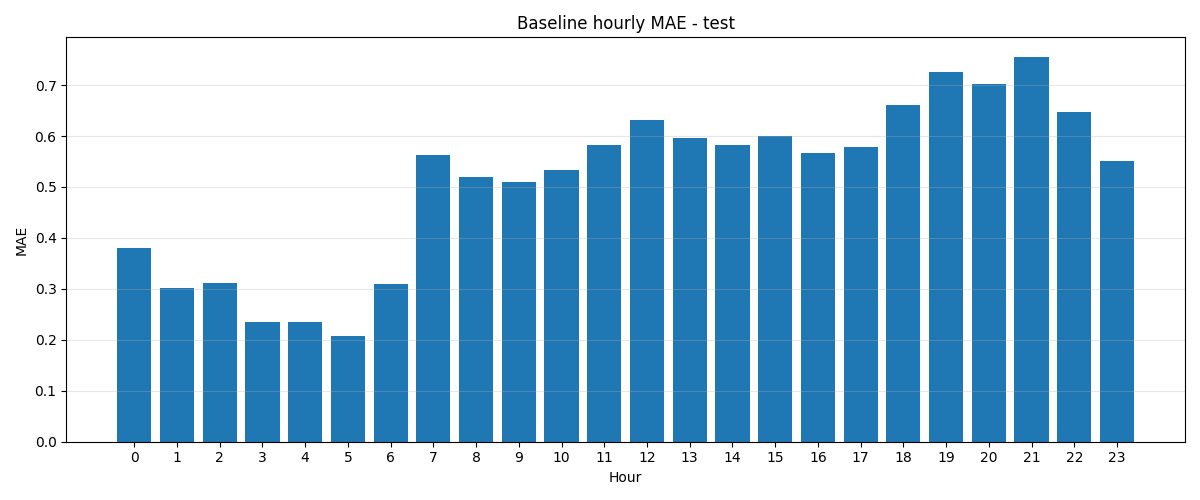

### baseline_test_hourly_wape.png

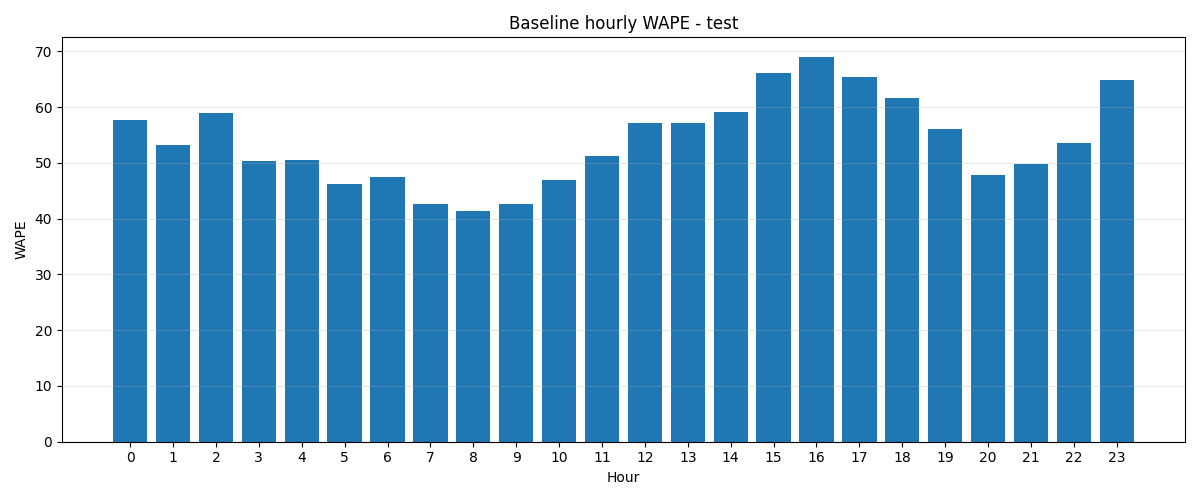

### baseline_test_actual_vs_predicted_scatter.png

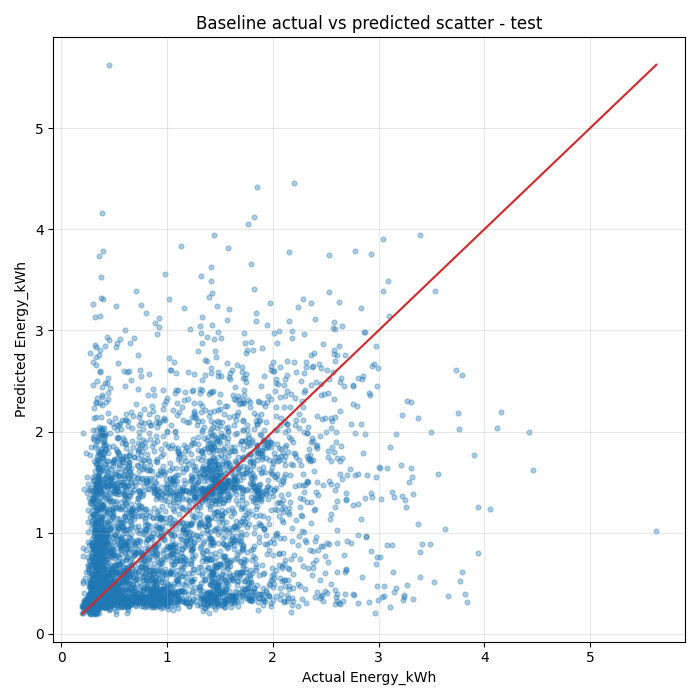

### baseline_test_error_distribution.png

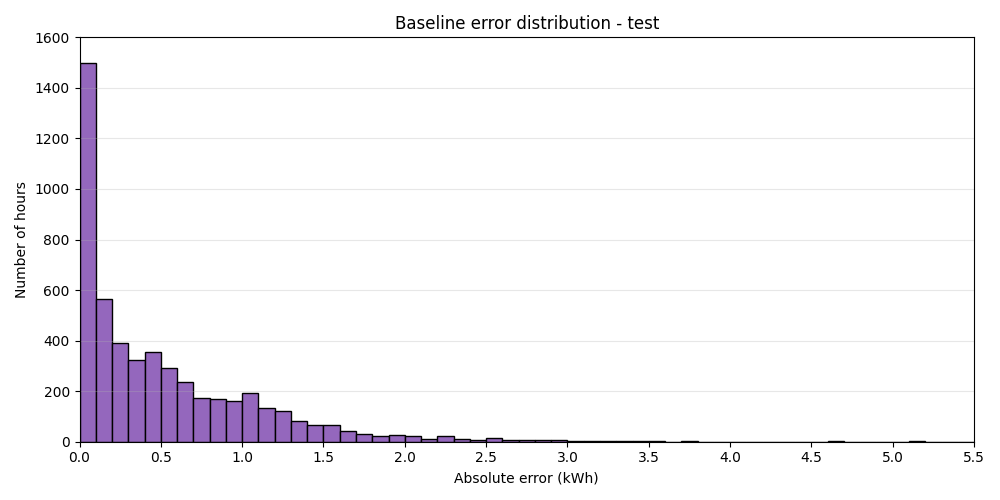

In [5]:
baseline_graphs = [
    "baseline_test_hourly_mae.png",
    "baseline_test_hourly_wape.png",
    "baseline_test_actual_vs_predicted_scatter.png",
    "baseline_test_error_distribution.png",
]

for graph_name in baseline_graphs:
    graph_path = BASELINE_GRAPHS_DIR / graph_name
    if graph_path.exists():
        display(Markdown(f"### {graph_name}"))
        display(Image(filename=str(graph_path)))

## 4. GRU ideja

GRU, Gated Recurrent Unit, je rekurentna neuronska mreža za sekvencijalne podatke. Za svaki sat u sekvenci model vidi sve ulazne feature-e, zatim GRU kroz svoje interno skriveno stanje pravi sažetak te istorije.

U kodu je finalna predikcija napravljena tako što se uzima izlaz poslednjeg vremenskog koraka GRU sloja i šalje u linearni sloj koji daje jednu vrednost: predikciju `Energy_kWh`.

In [36]:
from src import step06_gru_model as gru

display(Markdown("### Grid search prostor hiperparametara"))
display(pd.DataFrame({
    key: [", ".join(map(str, values))]
    for key, values in gru.GRU_GRID_SEARCH_SPACE.items()
}))

display(Markdown(f"Ukupan broj validnih GRU konfiguracija: **{len(gru.HYPERPARAMETER_CONFIGS)}**"))


### Grid search prostor hiperparametara

,sequence_length,batch_size,hidden_size,num_layers,dropout,learning_rate,max_epochs,patience
0,"12, 24, 48",64,"32, 64, 128","1, 2","0.0, 0.2, 0.3","0.001, 0.0005",80,10


Ukupan broj validnih GRU konfiguracija: **72**

## 5. Pravjenje sekvence, trening, validation i early stopping

Za svaki target sat pravi se prozor prethodnih `sequence_length` sati. Vrednost `sequence_length` nije fiksna u kodu, već je deo hiperparametara koji se porede kroz grid search.

Validation sekvence koriste kraj train skupa kao istorijski kontekst za prve validation sate. Test sekvence koriste kraj validation skupa kao istorijski kontekst za prve test sate. To ne znači da se model trenira na validation/test skupu; to samo obezbeđuje da prvi sati imaju prethodnih `sequence_length` sati istorije.

Model se trenira samo na train skupu. Validation skup se koristi za praćenje validation loss-a i early stopping. Ako se validation loss ne poboljša `patience` epoha zaredom, trening se prekida i vraća se najbolja sačuvana verzija modela.


## 6. Training history graf

Ovi grafovi pokazuju kako se menjaju `train_loss` i `validation_loss` kroz epohe. Najkorisniji su za objašnjenje overfitting-a i early stopping-a: ako train loss nastavlja da opada, a validation loss prestane da se poboljšava, model počinje sve više da se prilagođava train skupu umesto da bolje generalizuje.

In [39]:
summaries_path = GRU_LOGS_DIR / "gru_model_summaries.csv"
history_paths = sorted(GRU_LOGS_DIR.glob("*_training_history.csv"))

history_summary_rows = []
for path in history_paths:
    model_name = path.stem.removesuffix("_training_history")
    history_df = pd.read_csv(path)
    best_idx = history_df["validation_loss"].idxmin()
    best_row = history_df.loc[best_idx]
    history_summary_rows.append({
        "Model": model_name,
        "stopped_epoch": int(history_df["epoch"].iloc[-1]),
        "best_validation_epoch": int(best_row["epoch"]),
        "best_validation_loss": best_row["validation_loss"],
        "train_loss_at_best_validation": best_row["train_loss"],
        "final_train_loss": history_df["train_loss"].iloc[-1],
        "final_validation_loss": history_df["validation_loss"].iloc[-1],
    })

history_summary = pd.DataFrame(history_summary_rows)
if summaries_path.exists() and not history_summary.empty:
    metric_summary = pd.read_csv(summaries_path)[["Model", "validation_MAE", "test_MAE"]]
    history_summary = history_summary.merge(metric_summary, on="Model", how="left")
    best_history_model = history_summary.sort_values("validation_MAE").iloc[0]["Model"]
    selected_history_summary = history_summary[
        history_summary["Model"] == best_history_model
    ].sort_values("validation_MAE")
else:
    selected_history_summary = history_summary

display(selected_history_summary)


,Model,stopped_epoch,best_validation_epoch,best_validation_loss,train_loss_at_best_validation,final_train_loss,final_validation_loss,validation_MAE,test_MAE
40,gru_seq24_h64_l1_d0p0_lr0p0005_bs64,17,7,0.339953,0.35919,0.336253,0.34496,0.3714,0.3291


### Najbolji model po validation MAE: gru_seq24_h64_l1_d0p0_lr0p0005_bs64

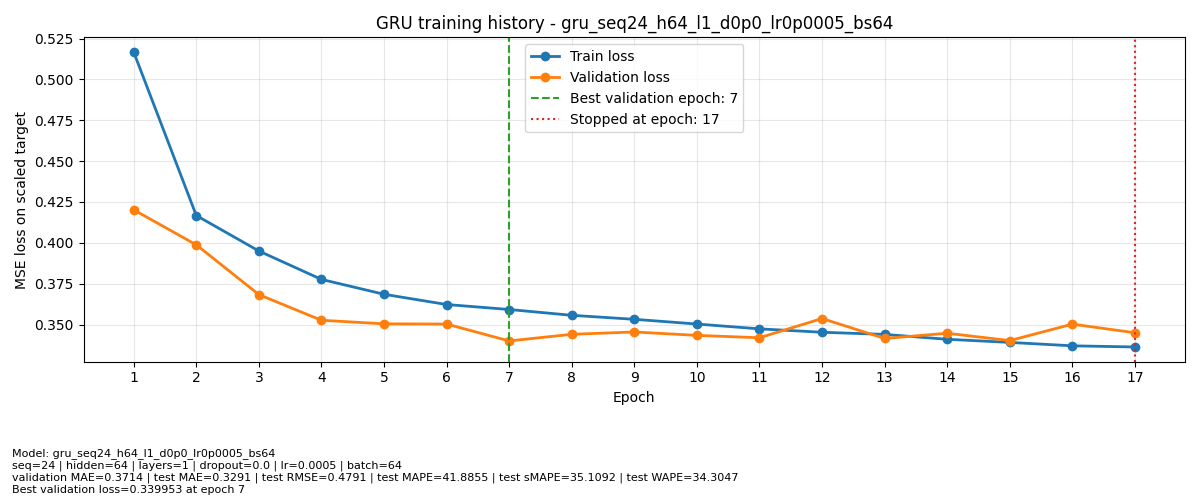

In [14]:
for row in selected_history_summary.itertuples(index=False):
    graph_path = GRU_GRAPHS_DIR / f"{row.Model}_training_history.png"
    if graph_path.exists():
        display(Markdown(f"### Najbolji model po validation MAE: {row.Model}"))
        display(Image(filename=str(graph_path)))


## 7. Rezultati GRU konfiguracija

Najbolja konfiguracija bira se po validation MAE, a test metrike se koriste za finalno izveštavanje.

In [11]:
summaries_path = GRU_LOGS_DIR / "gru_model_summaries.csv"
best_summary_path = GRU_LOGS_DIR / "best_gru_model_summary.csv"

if summaries_path.exists():
    gru_summaries = pd.read_csv(summaries_path)
    display(Markdown("### Top 10 GRU konfiguracija po validation MAE"))
    display(gru_summaries.sort_values("validation_MAE").head(10))

if best_summary_path.exists():
    display(Markdown("### Najbolji GRU po validation MAE"))
    display(pd.read_csv(best_summary_path))


### Top 10 GRU konfiguracija po validation MAE

,Model,sequence_length,batch_size,hidden_size,num_layers,dropout,learning_rate,max_epochs,patience,validation_MAE,validation_RMSE,validation_MAPE,validation_sMAPE,validation_WAPE,test_MAE,test_RMSE,test_MAPE,test_sMAPE,test_WAPE
33,gru_seq24_h64_l1_d0p0_lr0p0005_bs64,24,64,64,1,0.0,0.0005,80,10,0.3714,0.5384,38.0545,31.6183,29.7588,0.3291,0.4791,41.8855,35.1092,34.3047
9,gru_seq12_h64_l1_d0p0_lr0p0005_bs64,12,64,64,1,0.0,0.0005,80,10,0.3717,0.5379,38.9730,31.7031,29.7341,0.3318,0.4786,43.5760,35.5153,34.6108
54,gru_seq48_h32_l2_d0p3_lr0p001_bs64,48,64,32,2,0.3,0.0010,80,10,0.3718,0.5403,38.2607,31.7462,29.8152,0.3327,0.4812,43.7314,35.3755,34.5838
11,gru_seq12_h64_l2_d0p0_lr0p0005_bs64,12,64,64,2,0.0,0.0005,80,10,0.3718,0.5407,37.7116,31.7273,29.7435,0.3289,0.4796,41.8670,35.0022,34.3085
61,gru_seq48_h64_l2_d0p2_lr0p0005_bs64,48,64,64,2,0.2,0.0005,80,10,0.3723,0.5410,36.9146,31.5241,29.8613,0.3295,0.4800,41.4324,35.0173,34.2585
25,gru_seq24_h32_l1_d0p0_lr0p0005_bs64,24,64,32,1,0.0,0.0005,80,10,0.3724,0.5377,38.6467,31.8684,29.8395,0.3311,0.4799,42.3044,35.6066,34.5158
27,gru_seq24_h32_l2_d0p0_lr0p0005_bs64,24,64,32,2,0.0,0.0005,80,10,0.3725,0.5393,38.6957,31.6808,29.8471,0.3319,0.4845,42.6195,35.1934,34.5955
8,gru_seq12_h64_l1_d0p0_lr0p001_bs64,12,64,64,1,0.0,0.0010,80,10,0.3729,0.5405,38.2907,31.8821,29.8322,0.3303,0.4808,41.9157,35.6720,34.4552
35,gru_seq24_h64_l2_d0p0_lr0p0005_bs64,24,64,64,2,0.0,0.0005,80,10,0.3729,0.5364,39.1478,31.9738,29.8806,0.3283,0.4799,41.8357,34.8184,34.2255
59,gru_seq48_h64_l2_d0p0_lr0p0005_bs64,48,64,64,2,0.0,0.0005,80,10,0.3731,0.5395,38.3383,31.7417,29.9263,0.3350,0.4846,43.2672,35.4882,34.8276


### Najbolji GRU po validation MAE

,Model,selection_metric,sequence_length,batch_size,hidden_size,num_layers,dropout,learning_rate,max_epochs,patience,validation_MAE,validation_RMSE,validation_MAPE,validation_sMAPE,validation_WAPE,test_MAE,test_RMSE,test_MAPE,test_sMAPE,test_WAPE
0,gru_seq24_h64_l1_d0p0_lr0p0005_bs64,validation_MAE,24,64,64,1,0.0,0.0005,80,10,0.3714,0.5384,38.0545,31.6183,29.7588,0.3291,0.4791,41.8855,35.1092,34.3047


### Grupna analiza hiperparametara

Sledeći agregati ukratko pokazuju kako se performanse menjaju po pojedinačnim hiperparametrima.


In [16]:
hyperparameter_columns = [
    "sequence_length",
    "hidden_size",
    "num_layers",
    "dropout",
    "learning_rate",
]

summaries_path = summaries_path if "summaries_path" in globals() else GRU_LOGS_DIR / "gru_model_summaries.csv"

if summaries_path.exists():
    hyperparameter_summary = gru_summaries.copy() if "gru_summaries" in globals() else pd.read_csv(summaries_path)

    for parameter in hyperparameter_columns:
        grouped = (
            hyperparameter_summary
            .groupby(parameter)
            .agg(**{
                "Broj modela": ("Model", "count"),
                "Prosečan validation MAE": ("validation_MAE", "mean"),
                "Najbolji validation MAE": ("validation_MAE", "min"),
                "Prosečan test MAE": ("test_MAE", "mean"),
                "Najbolji test MAE": ("test_MAE", "min"),
            })
            .reset_index()
            .sort_values(parameter)
        )

        metric_columns = [
            "Prosečan validation MAE",
            "Najbolji validation MAE",
            "Prosečan test MAE",
            "Najbolji test MAE",
        ]
        grouped[metric_columns] = grouped[metric_columns].round(4)

        display(Markdown(f"#### {parameter}"))
        display(grouped)


#### sequence_length

,sequence_length,Broj modela,Prosečan validation MAE,Najbolji validation MAE,Prosečan test MAE,Najbolji test MAE
0,12,24,0.3768,0.3717,0.3355,0.3289
1,24,24,0.3751,0.3714,0.3337,0.3283
2,48,24,0.3760,0.3718,0.3349,0.3286


#### hidden_size

,hidden_size,Broj modela,Prosečan validation MAE,Najbolji validation MAE,Prosečan test MAE,Najbolji test MAE
0,32,24,0.3759,0.3718,0.3343,0.3305
1,64,24,0.3744,0.3714,0.3334,0.3283
2,128,24,0.3776,0.3736,0.3364,0.3318


#### num_layers

,num_layers,Broj modela,Prosečan validation MAE,Najbolji validation MAE,Prosečan test MAE,Najbolji test MAE
0,1,18,0.3754,0.3714,0.3341,0.3291
1,2,54,0.3761,0.3718,0.3349,0.3283


#### dropout

,dropout,Broj modela,Prosečan validation MAE,Najbolji validation MAE,Prosečan test MAE,Najbolji test MAE
0,0.0,36,0.3757,0.3714,0.3348,0.3283
1,0.2,18,0.3765,0.3723,0.3343,0.3283
2,0.3,18,0.3761,0.3718,0.3349,0.3286


#### learning_rate

,learning_rate,Broj modela,Prosečan validation MAE,Najbolji validation MAE,Prosečan test MAE,Najbolji test MAE
0,0.0005,36,0.3753,0.3714,0.3341,0.3283
1,0.0010,36,0.3766,0.3718,0.3353,0.3303


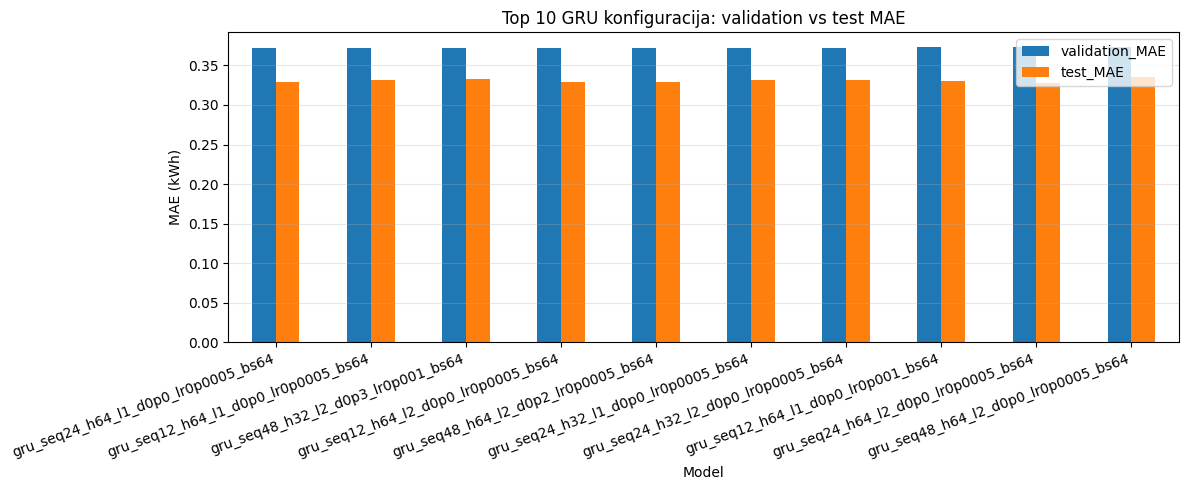

In [17]:
if summaries_path.exists():
    plot_df = pd.read_csv(summaries_path).sort_values("validation_MAE").head(10).set_index("Model")
    ax = plot_df[["validation_MAE", "test_MAE"]].plot(kind="bar", figsize=(12, 5))
    ax.set_title("Top 10 GRU konfiguracija: validation vs test MAE")
    ax.set_ylabel("MAE (kWh)")
    ax.grid(True, axis="y", alpha=0.3)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


## 8. GRU rezultati na test skupu

Za trenirane GRU konfiguracije generišu se grafovi greške po satu, scatter odnos stvarnih i predviđenih vrednosti i distribucija apsolutne greške. Pošto grid search trenira veliki broj modela, u notebook-u se radi preglednosti prikazuju grafovi trenutno najboljeg modela po `validation_MAE`.


## Najbolji GRU model: gru_seq24_h64_l1_d0p0_lr0p0005_bs64

### test_hourly_mae.png

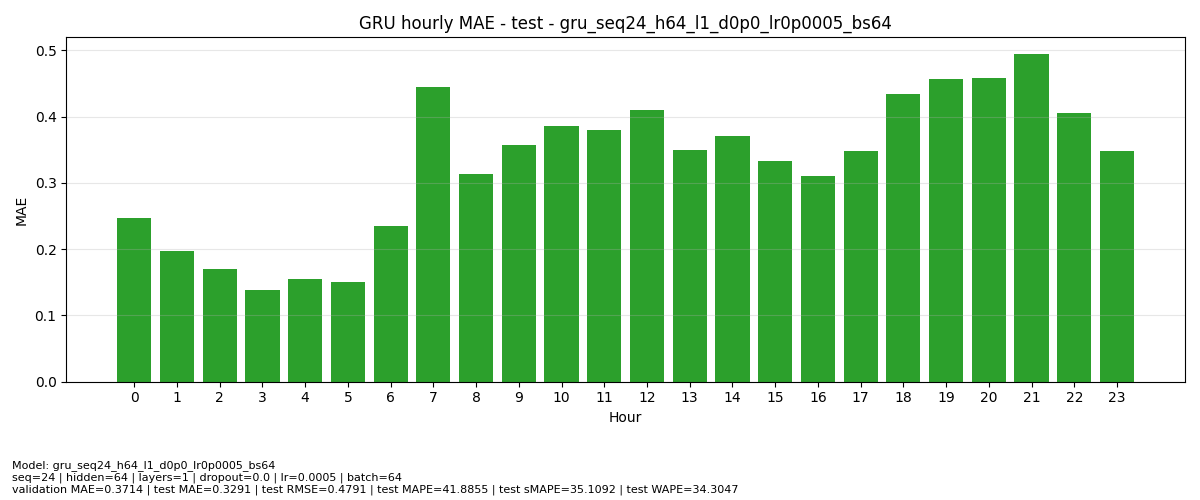

### test_hourly_wape.png

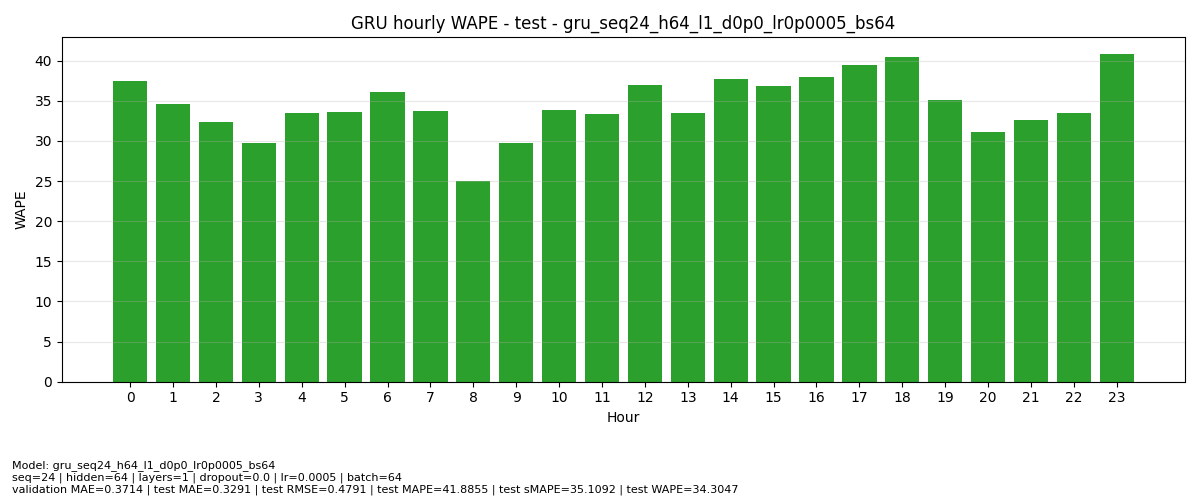

### test_actual_vs_predicted_scatter.png

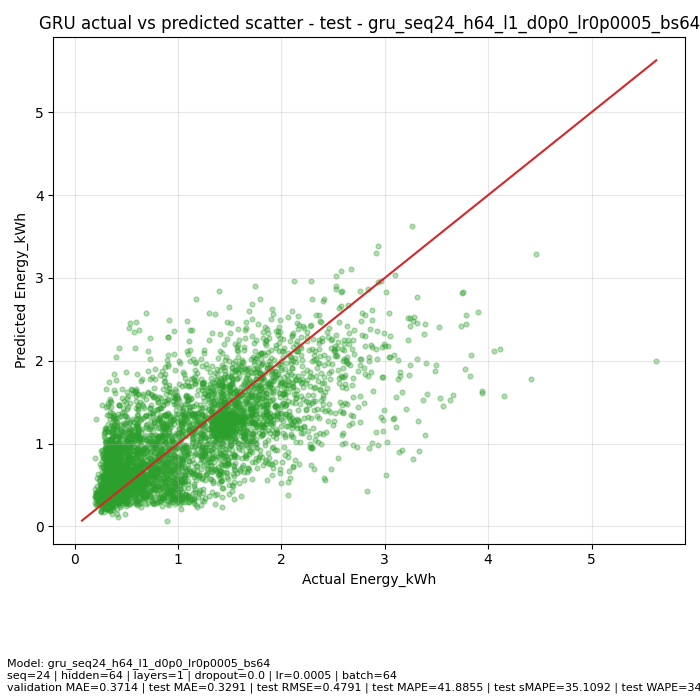

### test_error_distribution.png

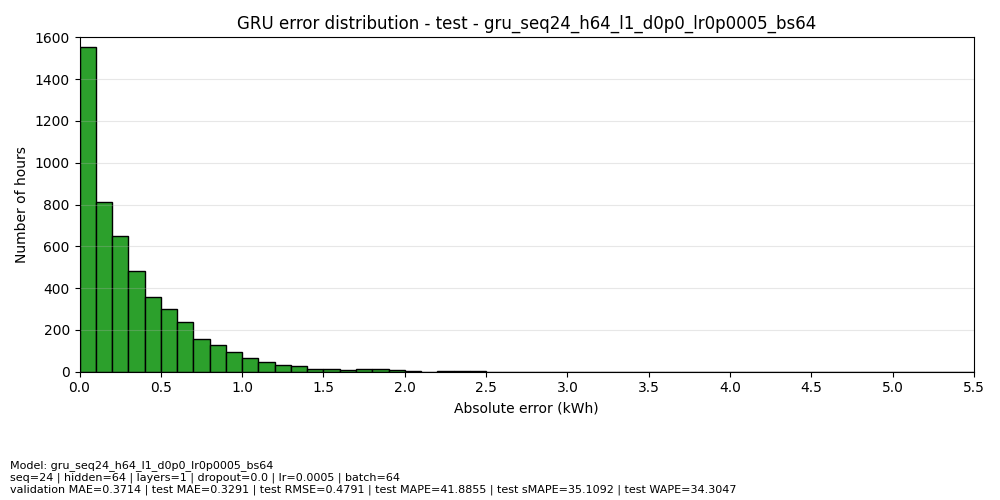

In [12]:
if best_summary_path.exists():
    model_names = pd.read_csv(best_summary_path)["Model"].tolist()
elif summaries_path.exists():
    model_names = [pd.read_csv(summaries_path).sort_values("validation_MAE").iloc[0]["Model"]]
else:
    model_names = sorted(path.name.split("_test_")[0] for path in GRU_GRAPHS_DIR.glob("*_test_hourly_mae.png"))[:1]

selected_graph_suffixes = [
    "test_hourly_mae.png",
    "test_hourly_wape.png",
    "test_actual_vs_predicted_scatter.png",
    "test_error_distribution.png",
]

for model_name in model_names:
    display(Markdown(f"## Najbolji GRU model: {model_name}"))
    for suffix in selected_graph_suffixes:
        graph_path = GRU_GRAPHS_DIR / f"{model_name}_{suffix}"
        if graph_path.exists():
            display(Markdown(f"### {suffix}"))
            display(Image(filename=str(graph_path)))


## 9. Baseline vs najbolji GRU

Poboljšanje koje GRU arhitektura donosi u odnosu na `lag_24h` baseline, uporedni prikaz.

,Report_Type,Dataset,Hour,Broj_redova,Better_Model_by_MAE,Baseline_MAE,GRU_MAE,MAE_Improvement_percent,Baseline_RMSE,GRU_RMSE,RMSE_Improvement_percent,Baseline_MAPE,GRU_MAPE,MAPE_Improvement_percent,Baseline_sMAPE,GRU_sMAPE,sMAPE_Improvement_percent,Baseline_WAPE,GRU_WAPE,WAPE_Improvement_percent
0,summary,test,NaN,5025,gru_seq24_h64_l1_d0p0_lr0p0005_bs64,0.5123,0.3291,35.7603,0.7611,0.4791,37.0516,66.8003,41.8855,37.2974,49.2873,35.1092,28.7662,53.4677,34.3047,35.8403


### best_gru_seq24_h64_l1_d0p0_lr0p0005_bs64_baseline_gru_compare_test_actual_vs_predicted_scatter.png

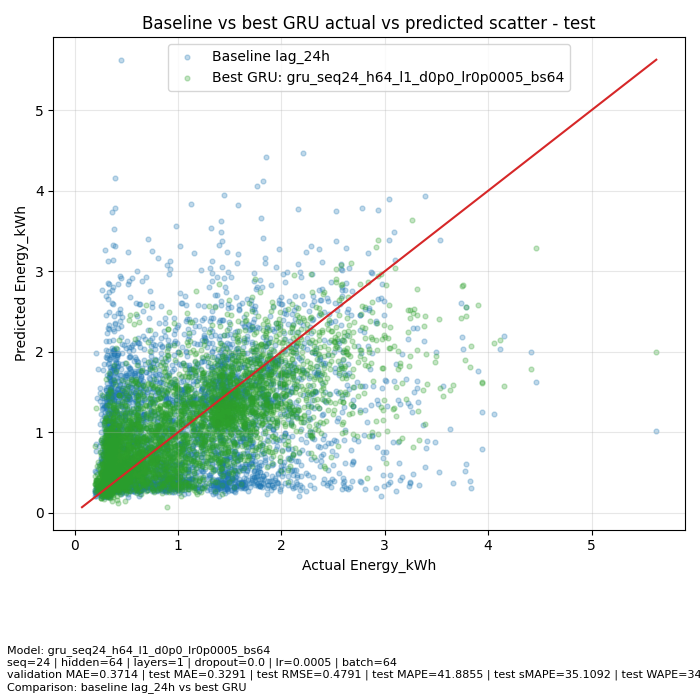

### best_gru_seq24_h64_l1_d0p0_lr0p0005_bs64_baseline_gru_compare_test_error_distribution.png

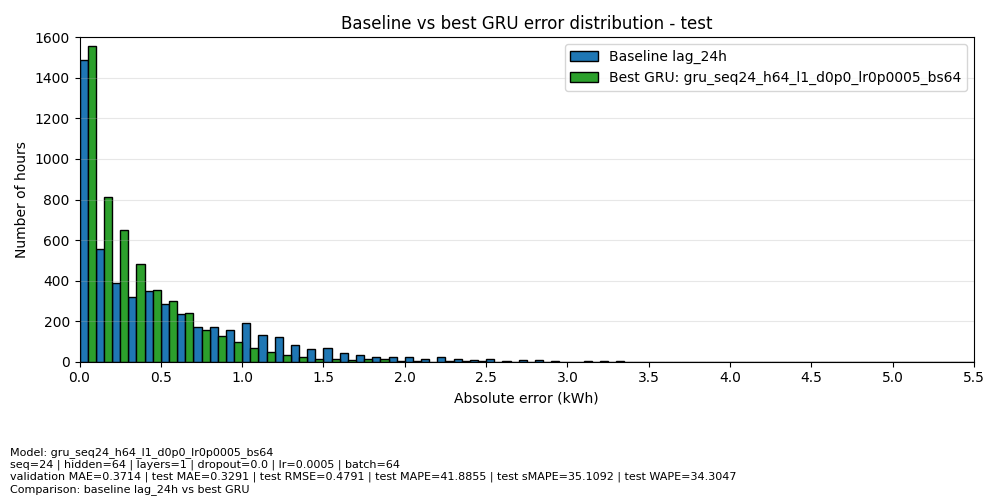

### best_gru_seq24_h64_l1_d0p0_lr0p0005_bs64_baseline_gru_compare_test_hourly_mae.png

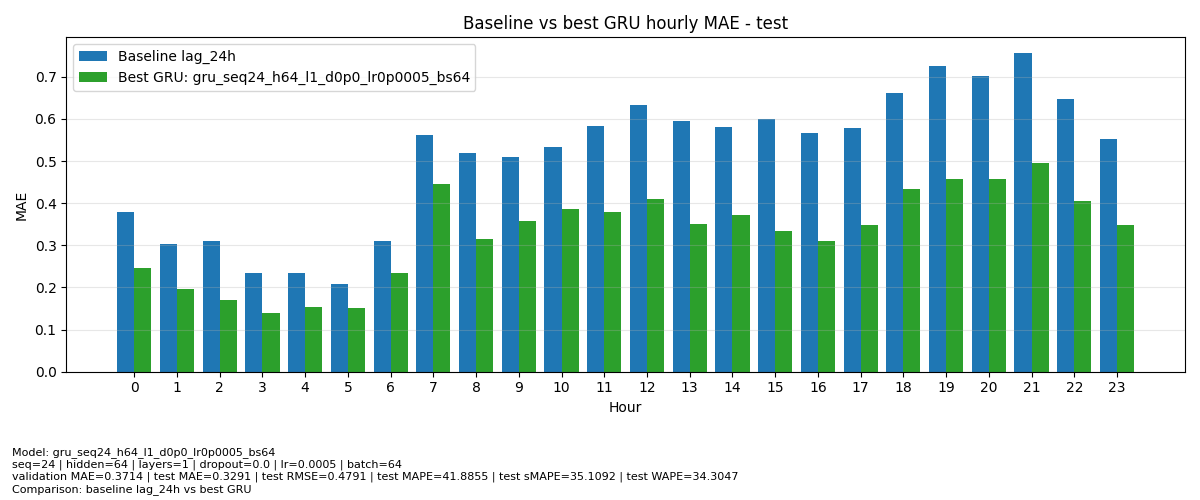

### best_gru_seq24_h64_l1_d0p0_lr0p0005_bs64_baseline_gru_compare_test_hourly_wape.png

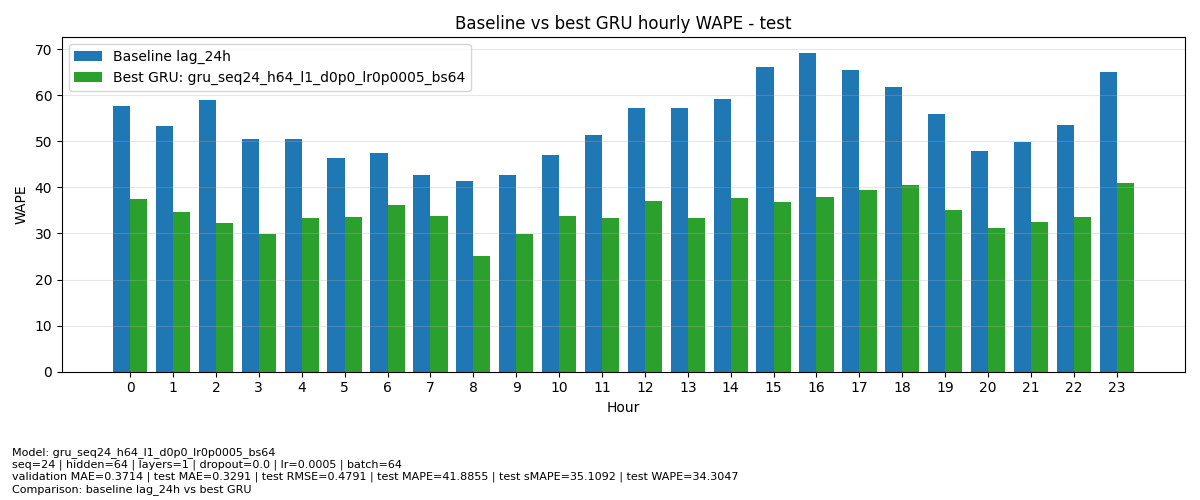

In [13]:
compare_report_path = COMPARE_LOGS_DIR / "baseline_gru_compare_report.csv"

if compare_report_path.exists():
    compare_report = pd.read_csv(compare_report_path)
    display(compare_report[compare_report["Report_Type"] == "summary"])

for graph_path in sorted(COMPARE_GRAPHS_DIR.glob("*.png")):
    display(Markdown(f"### {graph_path.name}"))
    display(Image(filename=str(graph_path)))


## 10. Zaključci nad rezultatima GRU modela

- Najbolja konfiguracija po glavnom kriterijumu izbora, `validation_MAE`, jeste `gru_seq24_h64_l1_d0p0_lr0p0005_bs64` (`sequence_length = 24`, `hidden_size = 64`, `num_layers = 1`, `dropout = 0.0` i `learning_rate = 0.0005`). Ona ima `validation_MAE = 0.3714`, što je najmanja validation greška među konfiguracijama iz grid search-a.
- Ostale metrike najboljeg modela: `test_MAE = 0.3291`, `test_RMSE = 0.4791` i `test_WAPE = 34.30%`.
- U odnosu na baseline `lag_24h`, izabrani GRU smanjuje MAE sa `0.5123` na `0.3291`, što je poboljšanje od oko `35.76%`. RMSE se smanjuje za oko `37.05%`, a WAPE sa `53.47%` na `34.30%`.
- Najveće apsolutne greške izabranog GRU modela na test skupu javljaju se oko sati: 21h (`0.4949 kWh`), 20h (`0.4585 kWh`), 19h (`0.4565 kWh`). To sugeriše da je večernja potrošnja promenljivija i teža za predikciju.
- Najbolji sati za predikciju su noćni i rani jutarnji periodi: 3h (`0.1385 kWh`), 5h (`0.1511 kWh`), 4h (`0.1548 kWh`), 2h (`0.1704 kWh`). To ima smisla jer je potrošnja tada stabilnija i manje zavisi od dnevnih aktivnosti ukućana.
- Glavni zaključak je da GRU uspešno koristi širi vremenski kontekst i dodatne feature-e, dok grid search omogućava da se izbor arhitekture zasniva na validation rezultatu, a ne na ručnom izboru nekoliko konfiguracija.
- **Zanimljivo je primetiti da na osnovu dobijenih rezultata za posmatrani skup podataka i opseg hiperparametara sa kojim je GRU model treniran, promena konfiguracije ne dovodi do značajnog poboljšanja niti pogoršanja performansi - ne može se izdvojiti jednoznačna zavisnost između izbora hiperparametara i kvaliteta rezultata. Zbog toga se nastavlja dalje predviđanje nad dataset-om, korišćenjem druge arhitekture neuronske mreže - LSTM Long Short-Term Memory neural network model.**


## 11. LSTM ideja

LSTM, Long Short-Term Memory, koristi isti pripremljeni skup podataka i isti princip sekvenci kao GRU, ali umesto GRU sloja koristi LSTM sloj sa memorijskom ćelijom. Ta memorijska ćelija pomaže modelu da zadrži informacije kroz duže vremenske zavisnosti.

Pošto je priprema podataka ista kao kod GRU modela, u nastavku se prikazuju samo LSTM-specifični delovi: prostor hiperparametara, arhitektura, najbolja konfiguracija i grafici.

In [40]:
from src import step08_lstm_model as lstm

display(Markdown("### Grid search prostor hiperparametara za LSTM"))
display(pd.DataFrame({
    key: [", ".join(map(str, values))]
    for key, values in lstm.LSTM_GRID_SEARCH_SPACE.items()
}))

### Grid search prostor hiperparametara za LSTM

,sequence_length,batch_size,hidden_size,num_layers,dropout,learning_rate,max_epochs,patience
0,"12, 24, 48",64,"32, 64, 128","1, 2","0.0, 0.2, 0.3","0.001, 0.0005",80,10


## 12. LSTM training history graf

Kao i kod GRU modela, training history graf prikazuje kretanje `train_loss` i `validation_loss` kroz epohe za najbolji LSTM model. Ovaj prikaz je koristan za proveru early stopping-a i odnosa između učenja na train skupu i generalizacije na validation skupu.

,Model,stopped_epoch,best_validation_epoch,best_validation_loss,train_loss_at_best_validation,final_train_loss,final_validation_loss,validation_MAE,test_MAE
68,lstm_seq48_h64_l2_d0p2_lr0p0005_bs64,20,10,0.341413,0.353908,0.328299,0.352124,0.3704,0.3267


### Najbolji LSTM model po validation MAE: lstm_seq48_h64_l2_d0p2_lr0p0005_bs64

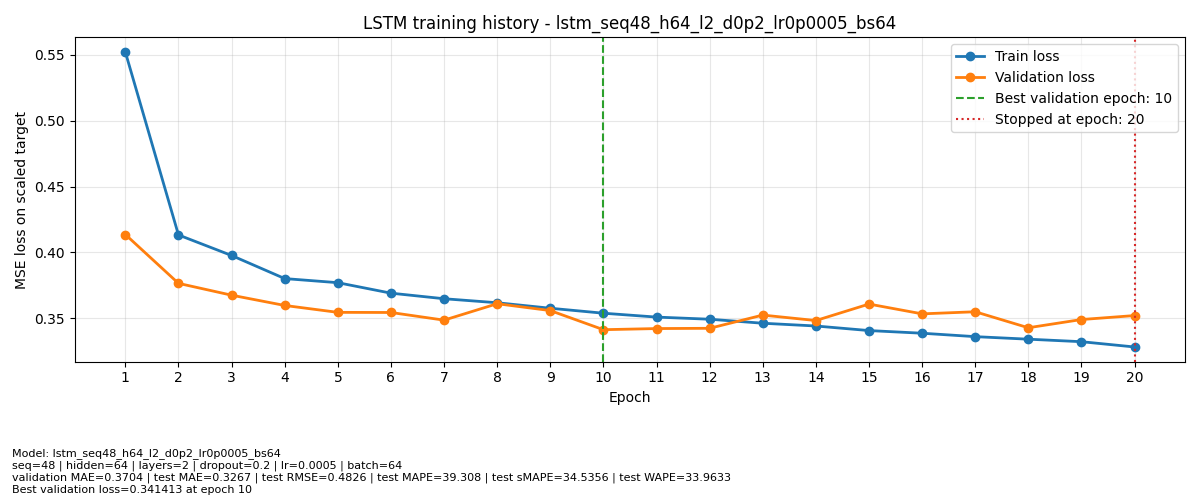

In [29]:
lstm_summaries_path = LSTM_LOGS_DIR / "lstm_model_summaries.csv"
lstm_history_paths = sorted(LSTM_LOGS_DIR.glob("*_training_history.csv"))
lstm_history_summary_rows = []

for path in lstm_history_paths:
    model_name = path.stem.removesuffix("_training_history")
    history_df = pd.read_csv(path)
    best_idx = history_df["validation_loss"].idxmin()
    best_row = history_df.loc[best_idx]
    lstm_history_summary_rows.append({
        "Model": model_name,
        "stopped_epoch": int(history_df["epoch"].iloc[-1]),
        "best_validation_epoch": int(best_row["epoch"]),
        "best_validation_loss": best_row["validation_loss"],
        "train_loss_at_best_validation": best_row["train_loss"],
        "final_train_loss": history_df["train_loss"].iloc[-1],
        "final_validation_loss": history_df["validation_loss"].iloc[-1],
    })

lstm_history_summary = pd.DataFrame(lstm_history_summary_rows)
if lstm_summaries_path.exists() and not lstm_history_summary.empty:
    metric_summary = pd.read_csv(lstm_summaries_path)[["Model", "validation_MAE", "test_MAE"]]
    lstm_history_summary = lstm_history_summary.merge(metric_summary, on="Model", how="left")
    best_lstm_history_model = lstm_history_summary.sort_values("validation_MAE").iloc[0]["Model"]
    selected_lstm_history_summary = lstm_history_summary[
        lstm_history_summary["Model"] == best_lstm_history_model
    ].sort_values("validation_MAE")
else:
    selected_lstm_history_summary = lstm_history_summary

display(selected_lstm_history_summary)

for row in selected_lstm_history_summary.itertuples(index=False):
    graph_path = LSTM_GRAPHS_DIR / f"{row.Model}_training_history.png"
    if graph_path.exists():
        display(Markdown(f"### Najbolji LSTM model po validation MAE: {row.Model}"))
        display(Image(filename=str(graph_path)))

## 13. LSTM rezultati

Najbolja LSTM konfiguracija bira se po istom kriterijumu kao kod GRU modela: najmanji `validation_MAE`. Test skup se koristi tek nakon izbora konfiguracije, za finalno izveštavanje.

In [31]:
lstm_summaries_path = LSTM_LOGS_DIR / "lstm_model_summaries.csv"
lstm_best_summary_path = LSTM_LOGS_DIR / "best_lstm_model_summary.csv"

if lstm_best_summary_path.exists():
    display(Markdown("### Najbolji LSTM po validation MAE"))
    display(pd.read_csv(lstm_best_summary_path))

### Najbolji LSTM po validation MAE

,Model,selection_metric,sequence_length,batch_size,hidden_size,num_layers,dropout,learning_rate,max_epochs,patience,validation_MAE,validation_RMSE,validation_MAPE,validation_sMAPE,validation_WAPE,test_MAE,test_RMSE,test_MAPE,test_sMAPE,test_WAPE
0,lstm_seq48_h64_l2_d0p2_lr0p0005_bs64,validation_MAE,48,64,64,2,0.2,0.0005,80,10,0.3704,0.5401,37.0087,31.3771,29.7089,0.3267,0.4826,39.308,34.5356,33.9633


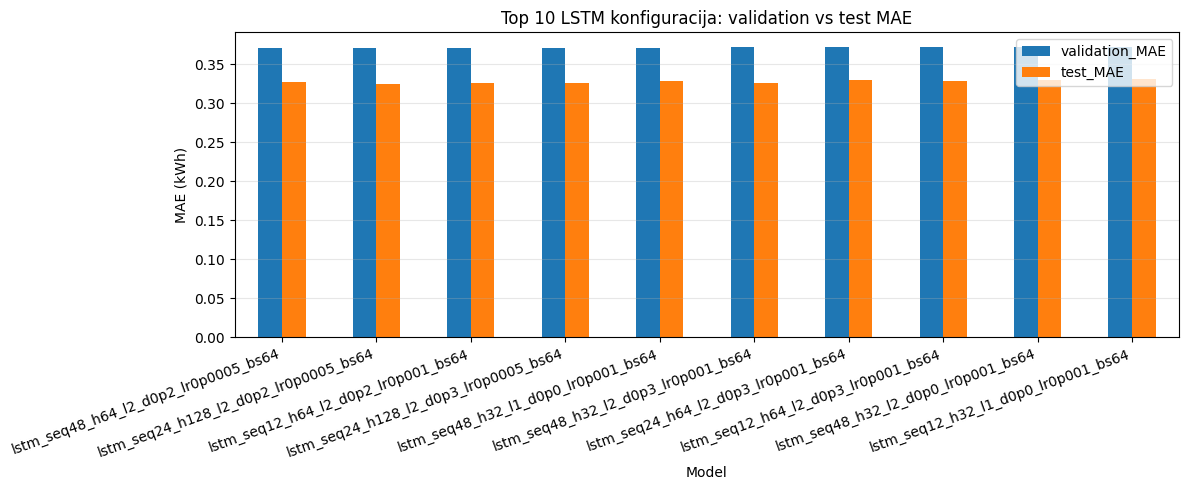

In [22]:
if lstm_summaries_path.exists():
    plot_df = pd.read_csv(lstm_summaries_path).sort_values("validation_MAE").head(10).set_index("Model")
    ax = plot_df[["validation_MAE", "test_MAE"]].plot(kind="bar", figsize=(12, 5))
    ax.set_title("Top 10 LSTM konfiguracija: validation vs test MAE")
    ax.set_ylabel("MAE (kWh)")
    ax.grid(True, axis="y", alpha=0.3)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

## 14. LSTM grafovi na test skupu

Prikazuju se grafovi trenutno najboljeg LSTM modela po `validation_MAE`: greška po satu, WAPE po satu, scatter odnos stvarnih i predviđenih vrednosti i distribucija apsolutne greške.

## Najbolji LSTM model: lstm_seq48_h64_l2_d0p2_lr0p0005_bs64

### test_hourly_mae.png

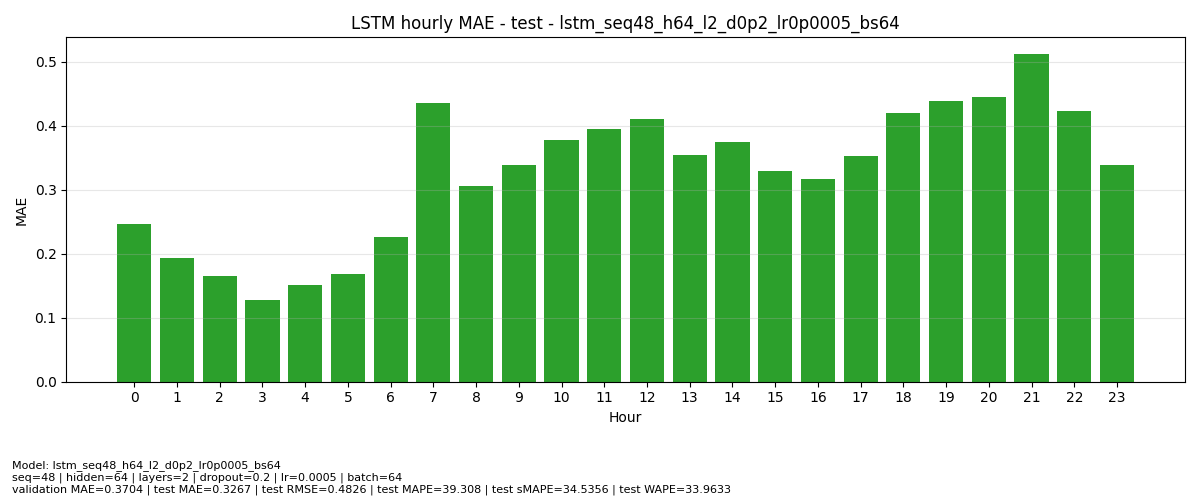

### test_hourly_wape.png

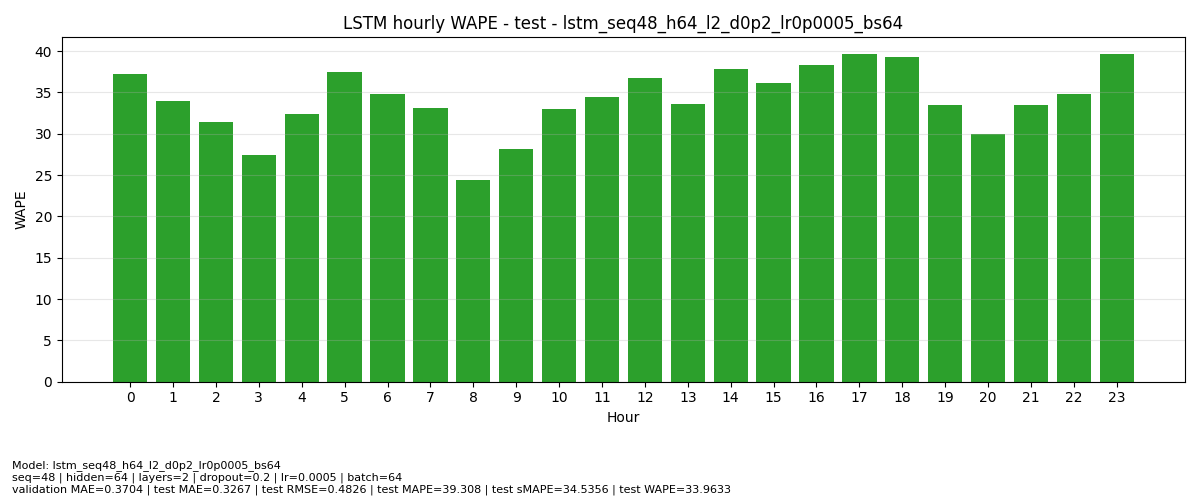

### test_actual_vs_predicted_scatter.png

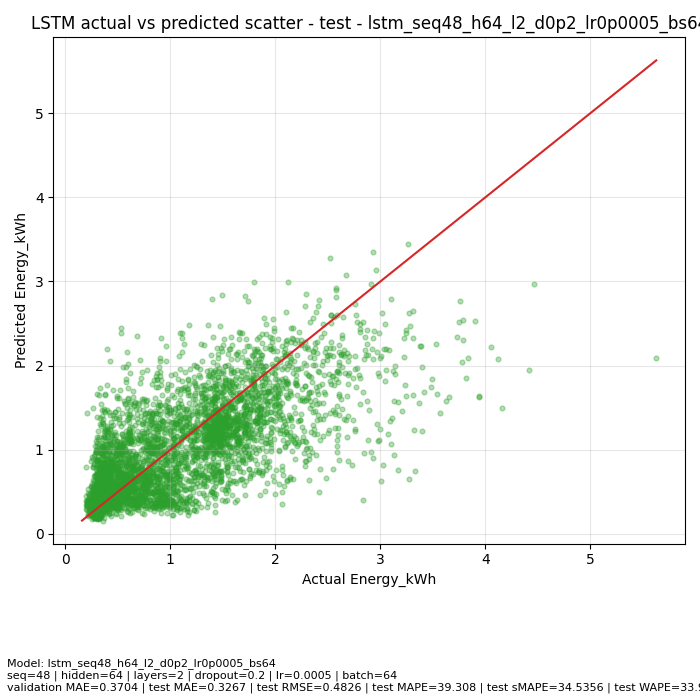

### test_error_distribution.png

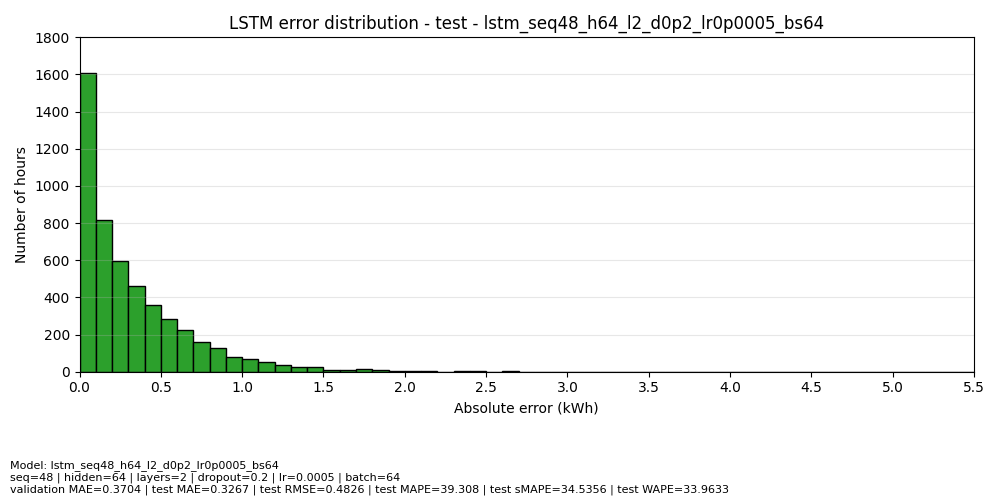

In [32]:
if lstm_best_summary_path.exists():
    lstm_model_names = pd.read_csv(lstm_best_summary_path)["Model"].tolist()
elif lstm_summaries_path.exists():
    lstm_model_names = [pd.read_csv(lstm_summaries_path).sort_values("validation_MAE").iloc[0]["Model"]]
else:
    lstm_model_names = sorted(path.name.split("_test_")[0] for path in LSTM_GRAPHS_DIR.glob("*_test_hourly_mae.png"))[:1]

selected_graph_suffixes = [
    "test_hourly_mae.png",
    "test_hourly_wape.png",
    "test_actual_vs_predicted_scatter.png",
    "test_error_distribution.png",
]

for model_name in lstm_model_names:
    display(Markdown(f"## Najbolji LSTM model: {model_name}"))
    for suffix in selected_graph_suffixes:
        graph_path = LSTM_GRAPHS_DIR / f"{model_name}_{suffix}"
        if graph_path.exists():
            display(Markdown(f"### {suffix}"))
            display(Image(filename=str(graph_path)))

## 15. Baseline vs najbolji LSTM

Ovaj deo proverava koliko LSTM poboljšava rezultat u odnosu na `lag_24h` baseline, istim principom kao za GRU model.

,Report_Type,Dataset,Hour,Broj_redova,Better_Model_by_MAE,Baseline_MAE,LSTM_MAE,MAE_Improvement_percent,Baseline_RMSE,LSTM_RMSE,RMSE_Improvement_percent,Baseline_MAPE,LSTM_MAPE,MAPE_Improvement_percent,Baseline_sMAPE,LSTM_sMAPE,sMAPE_Improvement_percent,Baseline_WAPE,LSTM_WAPE,WAPE_Improvement_percent
0,summary,test,NaN,4977,lstm_seq48_h64_l2_d0p2_lr0p0005_bs64,0.5123,0.3267,36.2288,0.7611,0.4826,36.5918,66.8003,39.308,41.156,49.2873,34.5356,29.93,53.4677,33.9633,36.4788


### best_lstm_seq48_h64_l2_d0p2_lr0p0005_bs64_baseline_lstm_compare_test_actual_vs_predicted_scatter.png

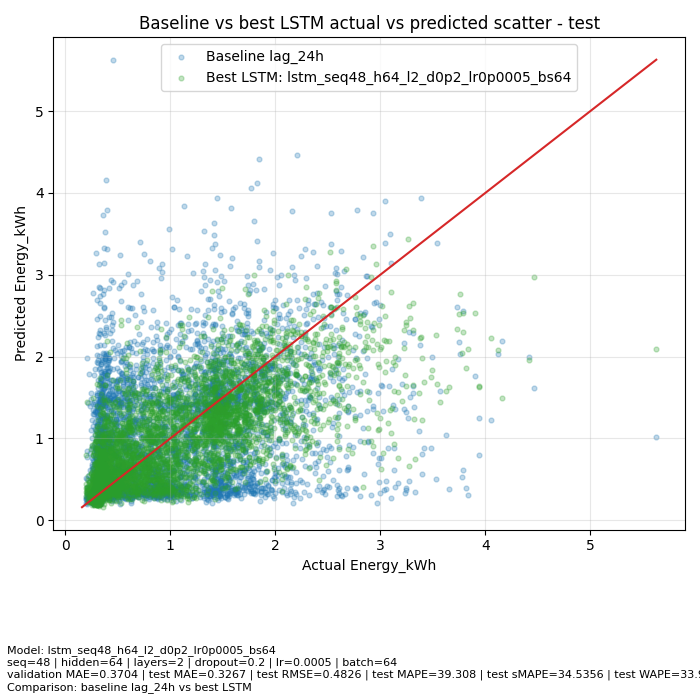

### best_lstm_seq48_h64_l2_d0p2_lr0p0005_bs64_baseline_lstm_compare_test_error_distribution.png

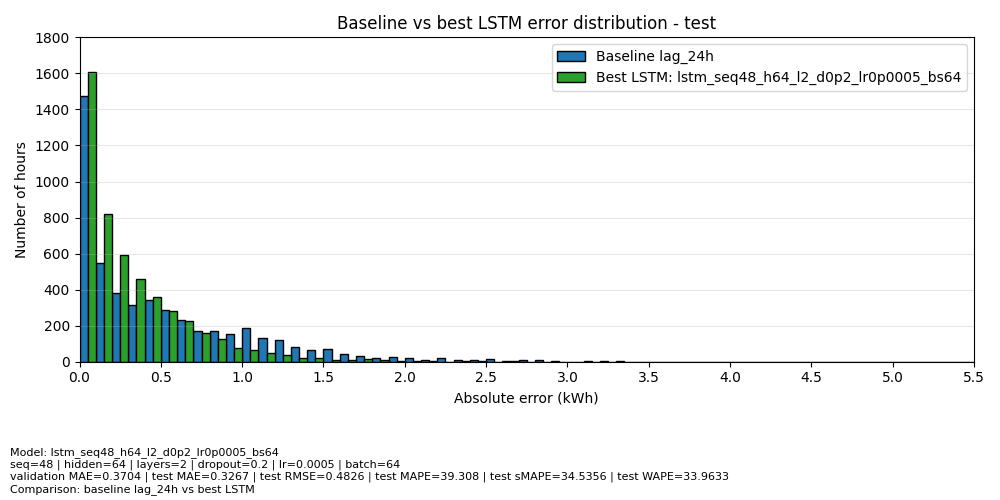

### best_lstm_seq48_h64_l2_d0p2_lr0p0005_bs64_baseline_lstm_compare_test_hourly_mae.png

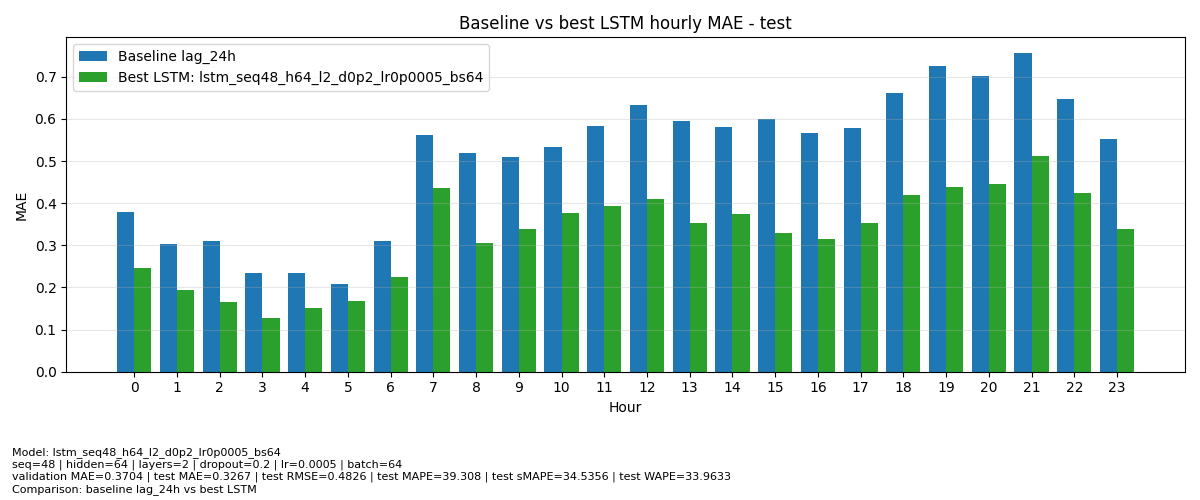

### best_lstm_seq48_h64_l2_d0p2_lr0p0005_bs64_baseline_lstm_compare_test_hourly_wape.png

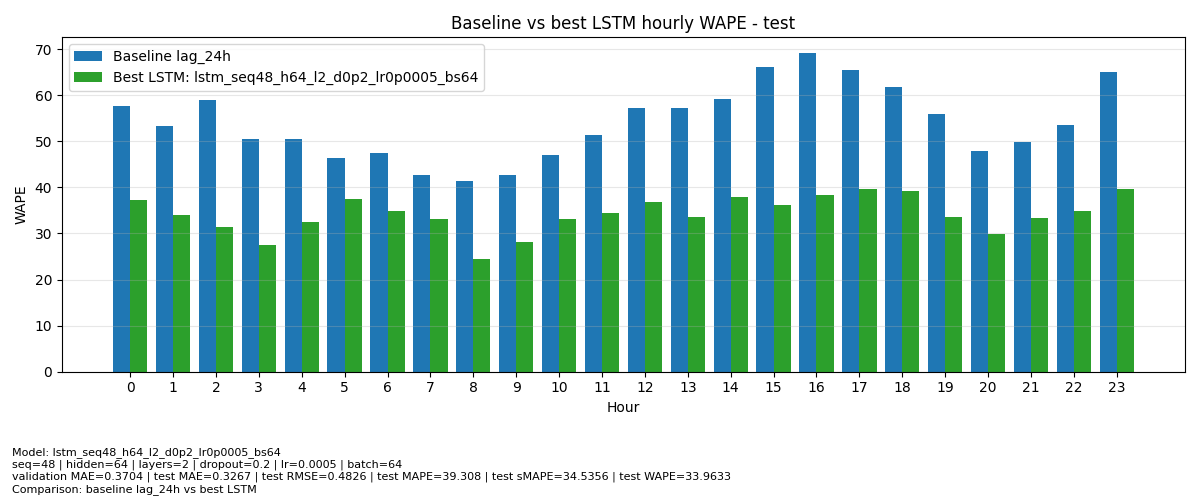

In [33]:
lstm_compare_report_path = COMPARE_LOGS_DIR / "baseline_lstm_compare_report.csv"

if lstm_compare_report_path.exists():
    lstm_compare_report = pd.read_csv(lstm_compare_report_path)
    display(lstm_compare_report[lstm_compare_report["Report_Type"] == "summary"])

for graph_path in sorted(LSTM_COMPARE_GRAPHS_DIR.glob("*.png")):
    display(Markdown(f"### {graph_path.name}"))
    display(Image(filename=str(graph_path)))

## 16. GRU vs LSTM poređenje

GRU i LSTM su trenirani nad istim pripremljenim podacima i istim prostorom hiperparametara. Zbog različite skale metrika, ovde se direktno poredi samo MAE na validation i test skupovima.

,Arhitektura,Model,validation_MAE,test_MAE
0,GRU,gru_seq24_h64_l1_d0p0_lr0p0005_bs64,0.3714,0.3291
1,LSTM,lstm_seq48_h64_l2_d0p2_lr0p0005_bs64,0.3704,0.3267


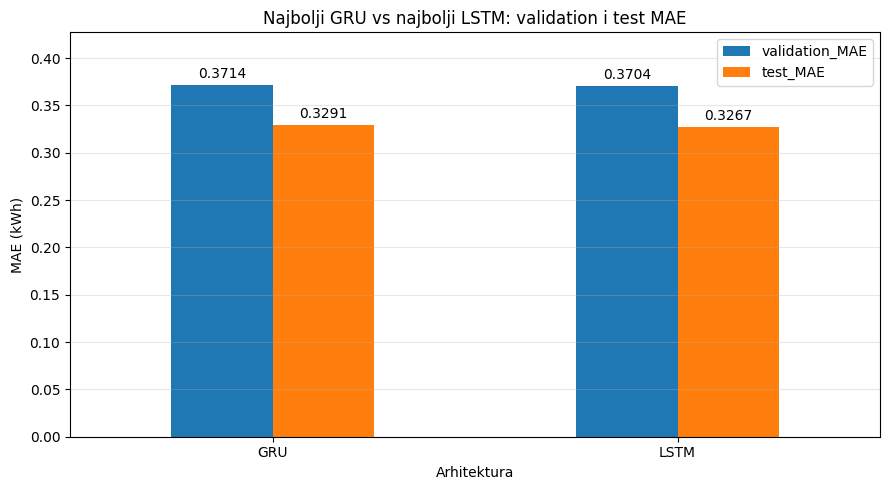

In [41]:
gru_best_summary_path = GRU_LOGS_DIR / "best_gru_model_summary.csv"
lstm_best_summary_path = LSTM_LOGS_DIR / "best_lstm_model_summary.csv"

comparison_rows = []
if gru_best_summary_path.exists():
    row = pd.read_csv(gru_best_summary_path).iloc[0]
    comparison_rows.append({
        "Arhitektura": "GRU",
        "Model": row["Model"],
        "validation_MAE": row["validation_MAE"],
        "test_MAE": row["test_MAE"],
    })
if lstm_best_summary_path.exists():
    row = pd.read_csv(lstm_best_summary_path).iloc[0]
    comparison_rows.append({
        "Arhitektura": "LSTM",
        "Model": row["Model"],
        "validation_MAE": row["validation_MAE"],
        "test_MAE": row["test_MAE"],
    })

model_comparison = pd.DataFrame(comparison_rows)
if not model_comparison.empty:
    display(model_comparison)

    plot_df = model_comparison.set_index("Arhitektura")[["validation_MAE", "test_MAE"]]
    ax = plot_df.plot(kind="bar", figsize=(9, 5))
    ax.set_title("Najbolji GRU vs najbolji LSTM: validation i test MAE")
    ax.set_ylabel("MAE (kWh)")
    ax.grid(True, axis="y", alpha=0.3)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.4f", padding=3)
    ax.set_ylim(0, plot_df.to_numpy().max() * 1.15)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


## 17. Zaključak GRU vs LSTM

- I GRU i LSTM modeli značajno su nadmašili baseline model. Na test skupu
baseline model ostvario je MAE od 0,5123 kWh, dok je najbolji GRU ostvario
MAE od 0,3291 kWh, a najbolji LSTM 0,3267 kWh. To predstavlja smanjenje
MAE greške od približno 35,8% za GRU i 36,2% za LSTM u odnosu na baseline.

- Grid search je pokazao da je najbolji GRU model imao relativno jednostavnu
arhitekturu sa jednim GRU slojem, 64 skrivene jedinice i sekvencom od 24
sata. Najbolji LSTM model imao je nešto složeniju arhitekturu sa dva LSTM
sloja, 64 skrivene jedinice, dropout vrednošću 0,2 i sekvencom od 48 sati.

- Ipak, razlika između najboljeg GRU i LSTM modela veoma je mala. Njihove MAE
i RMSE vrednosti jednake su na prve dve decimale, dok se razlike uglavnom
pojavljuju tek na trećoj ili četvrtoj decimali.

- Dobijeni rezultat takođe pokazuje da povećavanje broja slojeva i skrivenih
jedinica ne mora automatski dovesti do preciznije predikcije. Kada je
količina informacija u ulaznim podacima ograničena, kompleksniji model nema
dovoljno dodatnih obrazaca koje bi mogao da nauči. U tom slučaju povećanje
složenosti pre svega povećava vreme treniranja i rizik od overfitting-a.

- Preciznost bi potencijalno mogla da se poboljša dodavanjem dodatnih
informacija koje utiču na potrošnju, kao što su spoljašnja temperatura,
vremenski uslovi, prisustvo ukućana, korišćenje pojedinačnih uređaja, 
godišnji odmori i promene ponašanja korisnika.

- Na osnovu trenutnih rezultata može se zaključiti da oba rekurentna modela
uspešno uče obrasce potrošnje i značajno poboljšavaju baseline predikciju.
Međutim, zbog zanemarljive razlike u greškama, jednostavniji GRU model može
se smatrati praktičnijim izborom jer ostvaruje skoro identičnu preciznost
uz jednostavniju arhitekturu. LSTM je ostvario minimalno bolji MAE, ali
dobijeno poboljšanje nije dovoljno veliko da bi samo po sebi opravdalo
dodatnu složenost modela.